In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [28]:
df=pd.read_csv("/content/Titanic-Dataset.csv")

In [29]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [30]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [31]:
df=df[['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']]

In [32]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipython-input-694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [33]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)

/tmp/ipython-input-3717664479.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)


In [34]:
print(df.isnull().sum())

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64


In [35]:
df['Sex']=df['Sex'].map({'male':0,'female':1})
df['Embarked']=df['Embarked'].map({'S':0,'C':1,'Q':2})

In [36]:
X=df.drop('Survived',axis=1) #dropping Survived column from df and including remaining columns into X
Y=df['Survived']

In [37]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=42)


In [38]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

In [39]:
# Model Prediction
Y_pred=model.predict(X_test)
Y_prob=model.predict_proba(X_test) #function to calculate probablity values for prediction

In [40]:
print(Y_pred)

[0 0 0 1 1 1 1 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 0 1 0 1 1 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 1 0 1 1 1 0 1 1 0 0 1 0 0 0 1 1 1 1 1
 0 0 1 1 1 0 0 1 1 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 1
 0 1 0 1 0 0 0 1 0 0 1 1 0 0 0 1 1 1 0 1 0 0 1 0 1 1 0 0 1 0 1 0 0 1 1 0 0
 1 0 0 0 0 1 0 0 0 1 1 1 0 0 0 1 0 0 0 1 0 0 1 1 0 1 0 0 0 1 1 0 0 0 0 0 1
 0 0 0 0 1 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 0 0 0 0 1 0 1 0 0 0 1 0 1 0 0 1
 0 0 0 1 0 1 1 1 0 1 0 1 0 1 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 1 1 0 1 0 0 0 0 0]


In [41]:
print(Y_prob)

[[0.8988764  0.1011236 ]
 [0.77959842 0.22040158]
 [0.86201482 0.13798518]
 [0.11428629 0.88571371]
 [0.29375677 0.70624323]
 [0.07485305 0.92514695]
 [0.28592697 0.71407303]
 [0.90182882 0.09817118]
 [0.19974635 0.80025365]
 [0.07997076 0.92002924]
 [0.66307918 0.33692082]
 [0.93461036 0.06538964]
 [0.63758476 0.36241524]
 [0.86600738 0.13399262]
 [0.80662113 0.19337887]
 [0.06521302 0.93478698]
 [0.70082227 0.29917773]
 [0.28587763 0.71412237]
 [0.75356088 0.24643912]
 [0.67879602 0.32120398]
 [0.87763462 0.12236538]
 [0.59324583 0.40675417]
 [0.40583682 0.59416318]
 [0.86154225 0.13845775]
 [0.89535898 0.10464102]
 [0.91761916 0.08238084]
 [0.56652071 0.43347929]
 [0.77828471 0.22171529]
 [0.90055658 0.09944342]
 [0.43921215 0.56078785]
 [0.85787048 0.14212952]
 [0.36480941 0.63519059]
 [0.47581916 0.52418084]
 [0.42841683 0.57158317]
 [0.85355286 0.14644714]
 [0.88264424 0.11735576]
 [0.53570945 0.46429055]
 [0.28592697 0.71407303]
 [0.07286042 0.92713958]
 [0.89723227 0.10276773]


In [42]:
# Model Evaluation
print('Accuracy:',accuracy_score(Y_test,Y_pred))
conf_matrix=confusion_matrix(Y_test,Y_pred)
print('Confusion Matrix:',conf_matrix)
print('Classification Report:\n',classification_report(Y_test, Y_pred))

Accuracy: 0.8059701492537313
Confusion Matrix: [[136  21]
 [ 31  80]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.87      0.84       157
           1       0.79      0.72      0.75       111

    accuracy                           0.81       268
   macro avg       0.80      0.79      0.80       268
weighted avg       0.81      0.81      0.80       268



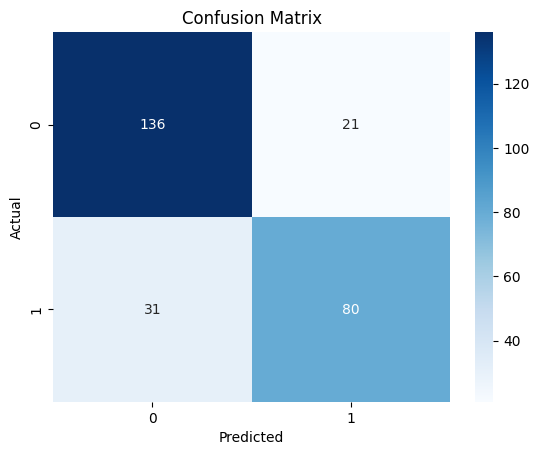

In [43]:
# Visualizing the Confusion Matrix
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()